# 2.2 Stock Split Analysis

This notebook checks whether downloaded closing prices remain reasonably smooth around stock split dates. A large jump may mean that a file needs manual review before pair selection.

It reads the original CSV files from `data/historical` and gets split dates from Yahoo Finance. It does not change or save any data.

## 1. Setup

All imports and settings are kept in one place. `MAX_PRICE_CHANGE` is a simple warning threshold: a move of 20% or more is flagged for review.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from IPython.display import display

# Find the data folder whether Jupyter starts in the project or notebooks folder.
PROJECT_FOLDER = Path.cwd()
if not (PROJECT_FOLDER / 'data').exists():
    PROJECT_FOLDER = PROJECT_FOLDER.parent

DATA_FOLDER = PROJECT_FOLDER / 'data' / 'Filter_historical'
MAX_PRICE_CHANGE = 20

if not DATA_FOLDER.exists():
    raise FileNotFoundError(f'Data folder not found: {DATA_FOLDER}')

print(f'Reading stock files from: {DATA_FOLDER}')

Reading stock files from: /home/lenovo/projects/pairs_trading_project/data/Filter_historical


## 2. Define the split check

For each split inside a stock's downloaded date range, the function compares the last close before the split with the first close on or after it. Yahoo normally supplies split-adjusted historical prices, so the values should usually be fairly close.

`Smooth = False` is a warning to investigate the event; it does not automatically mean the data is wrong. Normal market moves or unusual corporate actions can also create a large change.

In [4]:
RESULT_COLUMNS = [
    'Ticker', 'Split Date', 'Split Factor', 'Close Before',
    'Close After', 'Price Change (%)', 'Smooth'
]


def check_split_adjustment(ticker):
    """Return one row for each split inside a ticker's downloaded history."""
    ticker = ticker.upper()
    stock = pd.read_csv(DATA_FOLDER / f'{ticker}.csv', parse_dates=['Date'])
    stock = stock.sort_values('Date')

    # Yahoo uses a hyphen where some downloaded ticker names use a dot.
    yahoo_ticker = ticker.replace('.', '-')
    splits = yf.Ticker(yahoo_ticker).splits
    results = []

    for split_date, split_factor in splits.items():
        split_date = pd.Timestamp(split_date).tz_localize(None).normalize()
        before = stock.loc[stock['Date'] < split_date].tail(1)
        after = stock.loc[stock['Date'] >= split_date].head(1)

        # Skip splits outside the dates available in the CSV file.
        if before.empty or after.empty:
            continue

        close_before = before['Adj Close'].iloc[0]
        close_after = after['Adj Close'].iloc[0]
        price_change = (close_after / close_before - 1) * 100

        results.append({
            'Ticker': ticker,
            'Split Date': split_date.date(),
            'Split Factor': split_factor,
            'Close Before': close_before,
            'Close After': close_after,
            'Price Change (%)': round(price_change, 2),
            'Smooth': abs(price_change) < MAX_PRICE_CHANGE,
        })

    return pd.DataFrame(results, columns=RESULT_COLUMNS)

## 3. Check every downloaded stock

This cell runs the function for every CSV file. The Yahoo requests can take a few minutes. A failed ticker is printed, but it does not stop the remaining checks.

In [5]:
all_split_checks = []
failed_tickers = []

for stock_file in sorted(DATA_FOLDER.glob('*.csv')):
    ticker = stock_file.stem

    try:
        ticker_results = check_split_adjustment(ticker)
        if not ticker_results.empty:
            all_split_checks.append(ticker_results)
    except Exception as error:
        failed_tickers.append(ticker)
        print(f'Could not check {ticker}: {error}')

if all_split_checks:
    split_check_df = pd.concat(all_split_checks, ignore_index=True)
else:
    split_check_df = pd.DataFrame(columns=RESULT_COLUMNS)

print(f'Split events checked: {len(split_check_df)}')
print(f'Tickers that could not be checked: {len(failed_tickers)}')
split_check_df.head(10)

Split events checked: 158
Tickers that could not be checked: 0


,Ticker,Split Date,Split Factor,Close Before,Close After,Price Change (%),Smooth
0,AAPL,2020-08-31,4.000,120.955673,125.057541,3.39,True
1,AFL,2018-03-19,2.000,37.154198,36.706661,-1.20,True
2,AIV,2020-12-01,0.807,1.408737,1.468354,4.23,True
3,AIV,2020-12-15,9.295,1.511056,1.754788,16.13,True
4,AMCR,2026-01-15,0.200,42.815529,42.873783,0.14,True
5,AMZN,2022-06-06,20.000,122.349998,124.790001,1.99,True
6,ANET,2021-11-18,4.000,33.020000,33.137501,0.36,True
7,ANET,2024-12-04,4.000,103.614998,105.430000,1.75,True
8,APD,2016-10-03,1.081,108.871788,110.042183,1.08,True
9,APH,2021-03-05,2.000,28.567192,29.290405,2.53,True


## 4. Review the warnings

This table contains only events whose closing-price change reached the warning threshold. An empty table means every checked event passed this simple test.

In [6]:
flagged_splits = split_check_df.loc[~split_check_df['Smooth']].copy()
flagged_splits = flagged_splits.sort_values(
    'Price Change (%)', key=abs, ascending=False
)

print(f'Events to review: {len(flagged_splits)}')
flagged_splits

Events to review: 6


,Ticker,Split Date,Split Factor,Close Before,Close After,Price Change (%),Smooth
50,EQT,2018-11-13,1.8370,17.285431,39.374535,127.79,False
41,DHR,2016-07-05,1.3190,42.009678,67.727325,61.22,False
102,MNST,2026-08-11,2.0000,90.360001,45.529999,-49.61,False
154,XRX,2017-01-03,1.5180,12.272588,16.891397,37.64,False
28,COL,2016-06-01,0.1000,0.150000,0.200000,33.33,False
149,VTR,2015-08-18,0.8757,48.813263,37.305859,-23.57,False


### Investigation of the six flagged events

The warning test is useful, but it assumes that the observations immediately before and after a Yahoo `splits` date are consecutive trading days and that every event returned as a split is an ordinary share split. Neither assumption holds for all six rows. The conclusions below use the values in `flagged_splits` and the surrounding rows in the local CSV files.

Yahoo finance:

Close is the closing price after adjustments for splits.
Adjusted close is the closing price after adjustments for all applicable splits and dividend distributions.

| Event | Finding | Classification |
|---|---|---|
| EQT, 2018-11-13 (+127.79%) | The compared rows are 2018-11-12 and 2022-10-03, not adjacent trading days. EQT was removed from the S&P 500 effective 2018-11-13 and returned effective 2022-10-03 | Local filtering/data-gap artefact; not a one-day return |
| DHR, 2016-07-05 (+61.22%) | Danaher spun off Fortive; Yahoo's `Adj Close` adjustment changes discontinuously. | Corporate action mishandled for this test/Yahoo series; not a market move |
| MNST, 2026-08-11 (-49.61%) | A genuine 2-for-1 split occurred, but the local Yahoo history mixes adjusted and unadjusted pre-split days. The local Yahoo file is inconsistent around it: August 5 is $94.46 (unadjusted), August 6 is $47.08 (adjusted), August 7 reverts to $90.36 (unadjusted), and August 11 is $45.53 (adjusted); August 10 is missing altogether. An independent history reports split-adjusted closes of $47.23, $47.08, $45.18, $45.72, and $45.53 for August 5, 6, 7, 10, and 11 respectively. | Yahoo data error/inconsistent split adjustment |
| XRX, 2017-01-03 (+37.64%) | Xerox distributed Conduent; Yahoo labels/adjusts the spin-off like a split. Xerox completed the Conduent separation at year-end 2016. Holders received one CNDT share for every five XRX shares, and the two companies traded separately from 2017-01-03. | Corporate action mishandled for this test/Yahoo series; not a market move |
| COL, 2016-06-01 (+33.33%) | The intended S&P 500 constituent was Rockwell Collins (NYSE: COL). The file is penny-stock data associated with a Canadian `COL` security 1-for-10 consolidation, not Rockwell Collins. The 10-1 consolidation is the inverse of Yahoo's displayed 0.1 factor. this file should be rejected and, if Rockwell Collins is required, replaced using an identifier-aware historical source. | Wrong security caused by ticker collision/reuse |
| VTR, 2015-08-18 (-23.57%) | Ventas distributed Care Capital Properties and began trading ex-distribution. It was a real ex-distribution price change, while Yahoo's VTR-only adjusted series does not neutralize the value transferred to CCP. A proper return calculation must include the distributed CCP shares (or use a verified total-return series). | Real spin-off value transfer, not an abnormal market fall; Yahoo `Adj Close` is unsuitable here |

## 5. Visual review of the abnormal events

The function below uses the same chart style as the Apple example and displays five available observations on either side of each flagged event. Using available rows rather than a fixed calendar window is important for EQT because its filtered history contains a multi-year membership gap.

In [7]:
def plot_split_event(ticker, split_date, split_factor, trading_days=5):
    """Display nearby prices and plot one flagged corporate-action event."""
    stock = pd.read_csv(DATA_FOLDER / f'{ticker}.csv', parse_dates=['Date'])
    stock = stock.sort_values('Date').reset_index(drop=True)
    split_date = pd.Timestamp(split_date)

    after_positions = stock.index[stock['Date'] >= split_date]
    if after_positions.empty:
        print(f'{ticker}: no observation on or after {split_date.date()}')
        return

    event_position = after_positions[0]
    split_period = stock.iloc[
        max(0, event_position - trading_days):event_position + trading_days
    ][['Date', 'Close', 'Adj Close']]

    display(split_period)

    plt.figure(figsize=(10, 5))
    plt.plot(split_period['Date'], split_period['Close'], marker='o')
    plt.axvline(
        split_date,
        color='red',
        linestyle='--',
        label=f'{split_factor:g} split factor',
    )
    plt.title(f'{ticker} closing price around the {split_date.date()} event')
    plt.xlabel('Date')
    plt.ylabel('Closing price (USD)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

,Date,Close,Adj Close
969,2018-11-06,19.063690,17.475061
970,2018-11-07,18.600981,17.050909
971,2018-11-08,18.943930,17.365273
972,2018-11-09,19.542732,17.914181
973,2018-11-12,18.856833,17.285431
974,2022-10-03,41.750000,39.374535
975,2022-10-04,44.910000,42.354740
976,2022-10-05,45.340000,42.760265
977,2022-10-06,43.939999,41.439922
978,2022-10-07,43.169998,40.713737


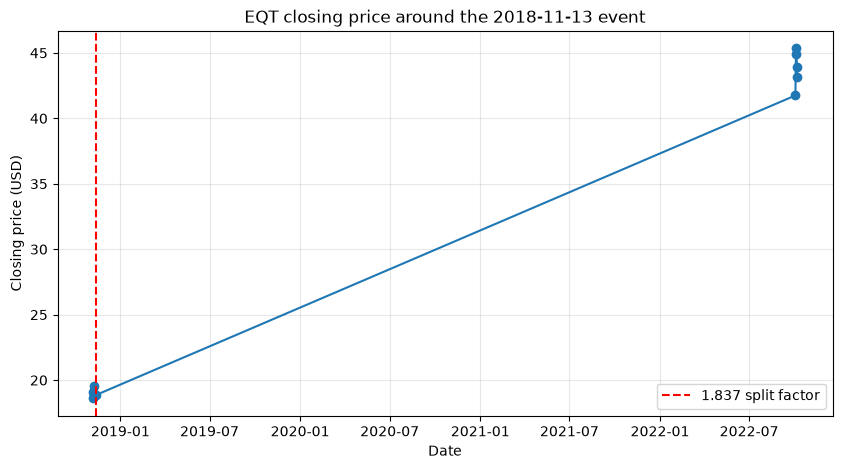

,Date,Close,Adj Close
373,2016-06-27,65.410614,39.956829
374,2016-06-28,65.948303,40.285271
375,2016-06-29,67.285820,41.102310
376,2016-06-30,67.884010,41.467712
377,2016-07-01,68.771202,42.009678
378,2016-07-05,71.276596,67.727325
379,2016-07-06,71.471634,67.912659
380,2016-07-07,71.542557,67.980034
381,2016-07-08,71.684395,68.114830
382,2016-07-11,70.992905,67.457756


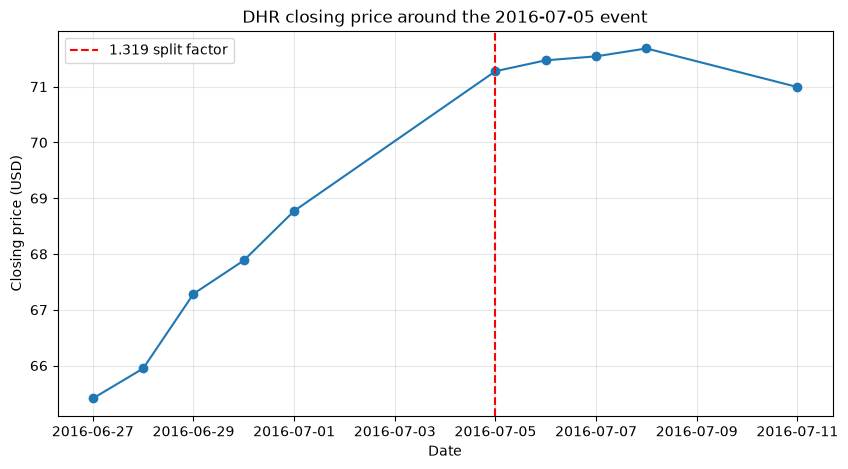

,Date,Close,Adj Close
2911,2026-08-03,93.550003,93.550003
2912,2026-08-04,94.180000,94.180000
2913,2026-08-05,94.459999,94.459999
2914,2026-08-06,47.080002,47.080002
2915,2026-08-07,90.360001,90.360001
2916,2026-08-11,45.529999,45.529999
2917,2026-08-12,45.980000,45.980000
2918,2026-08-13,46.680000,46.680000
2919,2026-08-14,46.820000,46.820000
2920,2026-08-17,45.520000,45.520000


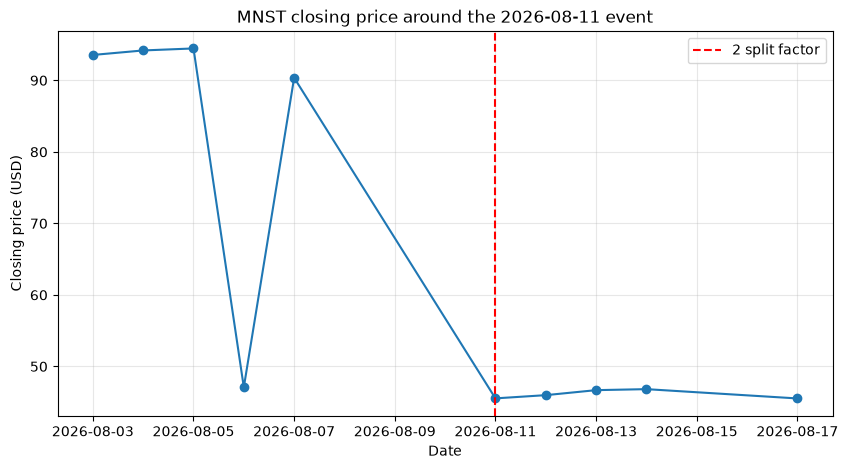

,Date,Close,Adj Close
499,2016-12-23,23.583664,12.581860
500,2016-12-27,23.557312,12.567807
501,2016-12-28,23.083004,12.314763
502,2016-12-29,22.977602,12.258529
503,2016-12-30,23.003954,12.272588
504,2017-01-03,27.559999,16.891397
505,2017-01-04,28.600000,17.528811
506,2017-01-05,28.480000,17.455252
507,2017-01-06,28.040001,17.185581
508,2017-01-09,27.879999,17.087519


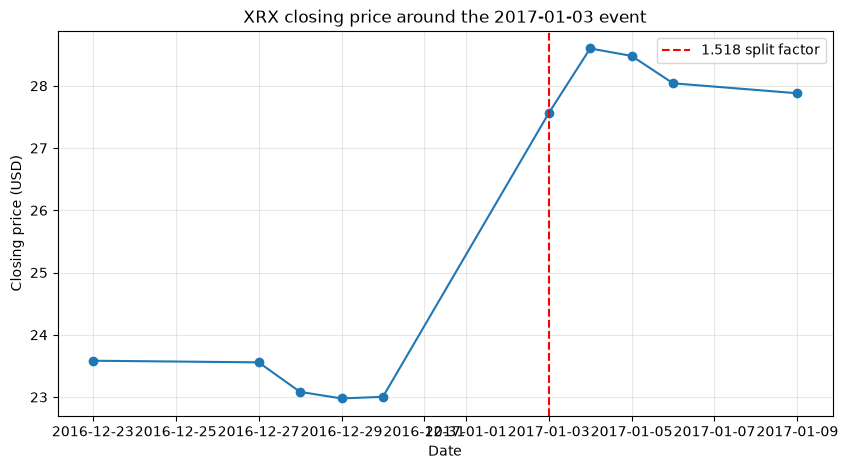

,Date,Close,Adj Close
344,2016-05-24,0.200,0.200
345,2016-05-25,0.200,0.200
346,2016-05-26,0.200,0.200
347,2016-05-27,0.200,0.200
348,2016-05-31,0.150,0.150
349,2016-06-01,0.200,0.200
350,2016-06-02,0.150,0.150
351,2016-06-03,0.150,0.150
352,2016-06-06,0.135,0.135
353,2016-06-07,0.135,0.135


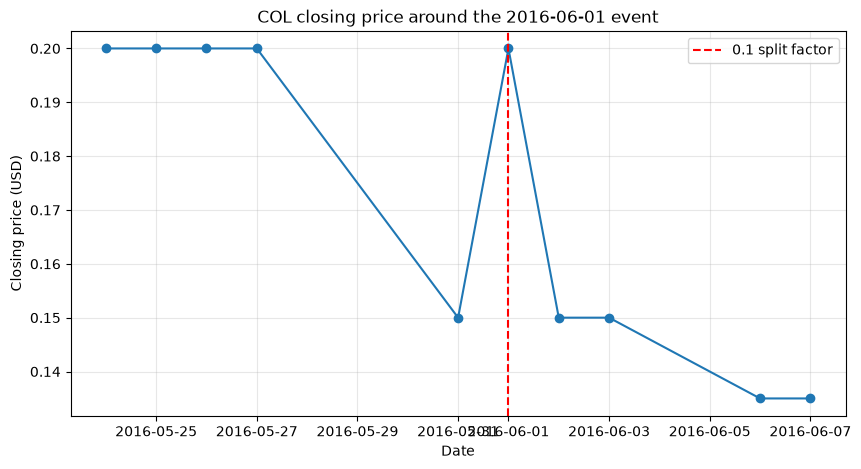

,Date,Close,Adj Close
152,2015-08-11,77.058350,48.072365
153,2015-08-12,77.617905,48.421444
154,2015-08-13,77.480873,48.335953
155,2015-08-14,78.097519,48.720650
156,2015-08-17,78.245972,48.813263
157,2015-08-18,59.799999,37.305859
158,2015-08-19,60.049999,37.461815
159,2015-08-20,60.549999,37.773739
160,2015-08-21,59.599998,37.181095
161,2015-08-24,56.869999,35.477993


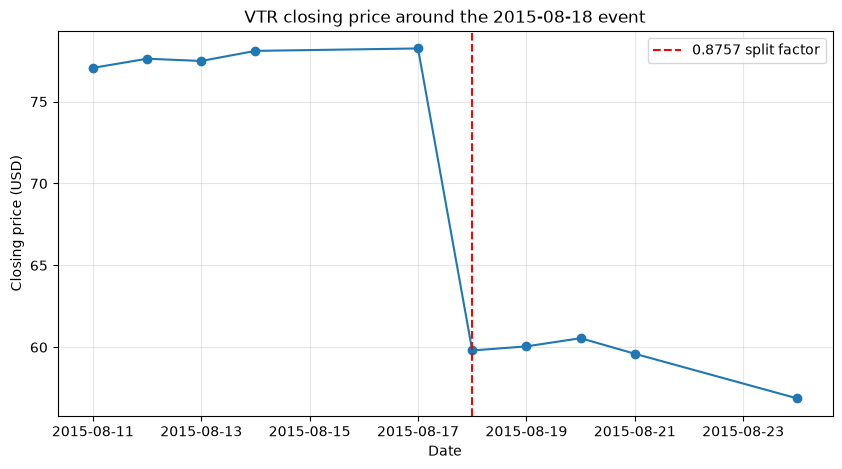

In [8]:
for _, event in flagged_splits.iterrows():
    plot_split_event(
        ticker=event['Ticker'],
        split_date=event['Split Date'],
        split_factor=event['Split Factor'],
    )

## Conclusion

Start with `flagged_splits` when reviewing the data. If an event looks suspicious, compare it with the original Yahoo history before deciding whether to exclude or replace the stock file. No files are modified by this notebook.